# 1. Data Loading and Exploration
This section loads the dataset, removes the unnecessary 'Serial No.' column, and explores feature distributions and correlations using both `pairplot` and a correlation heatmap. The heatmap allows us to mathematically confirm which two features are the most correlated.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

df = pd.read_csv('Admission.csv')

if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

display(df.head())

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


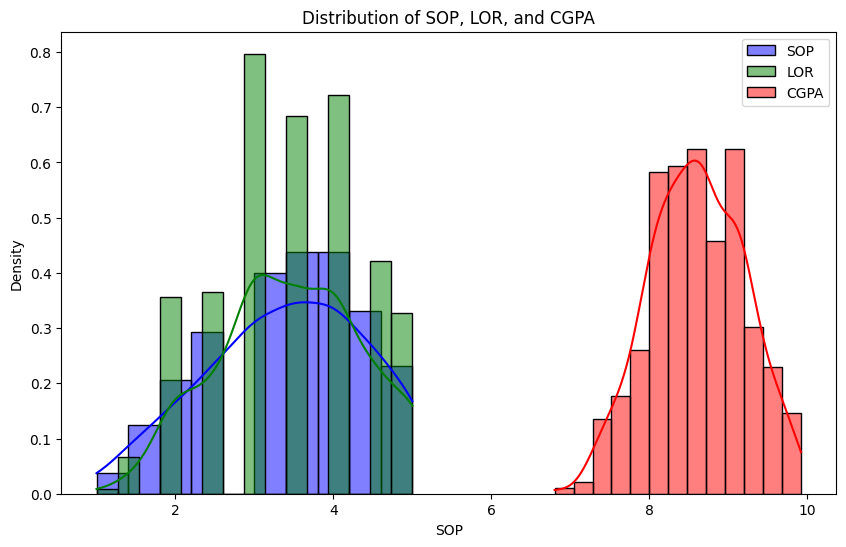

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SOP'], kde=True, color='blue', label='SOP', stat='density')
sns.histplot(df['LOR'], kde=True, color='green', label='LOR', stat='density')
sns.histplot(df['CGPA'], kde=True, color='red', label='CGPA', stat='density')
plt.title('Distribution of SOP, LOR, and CGPA')
plt.legend()
plt.show()

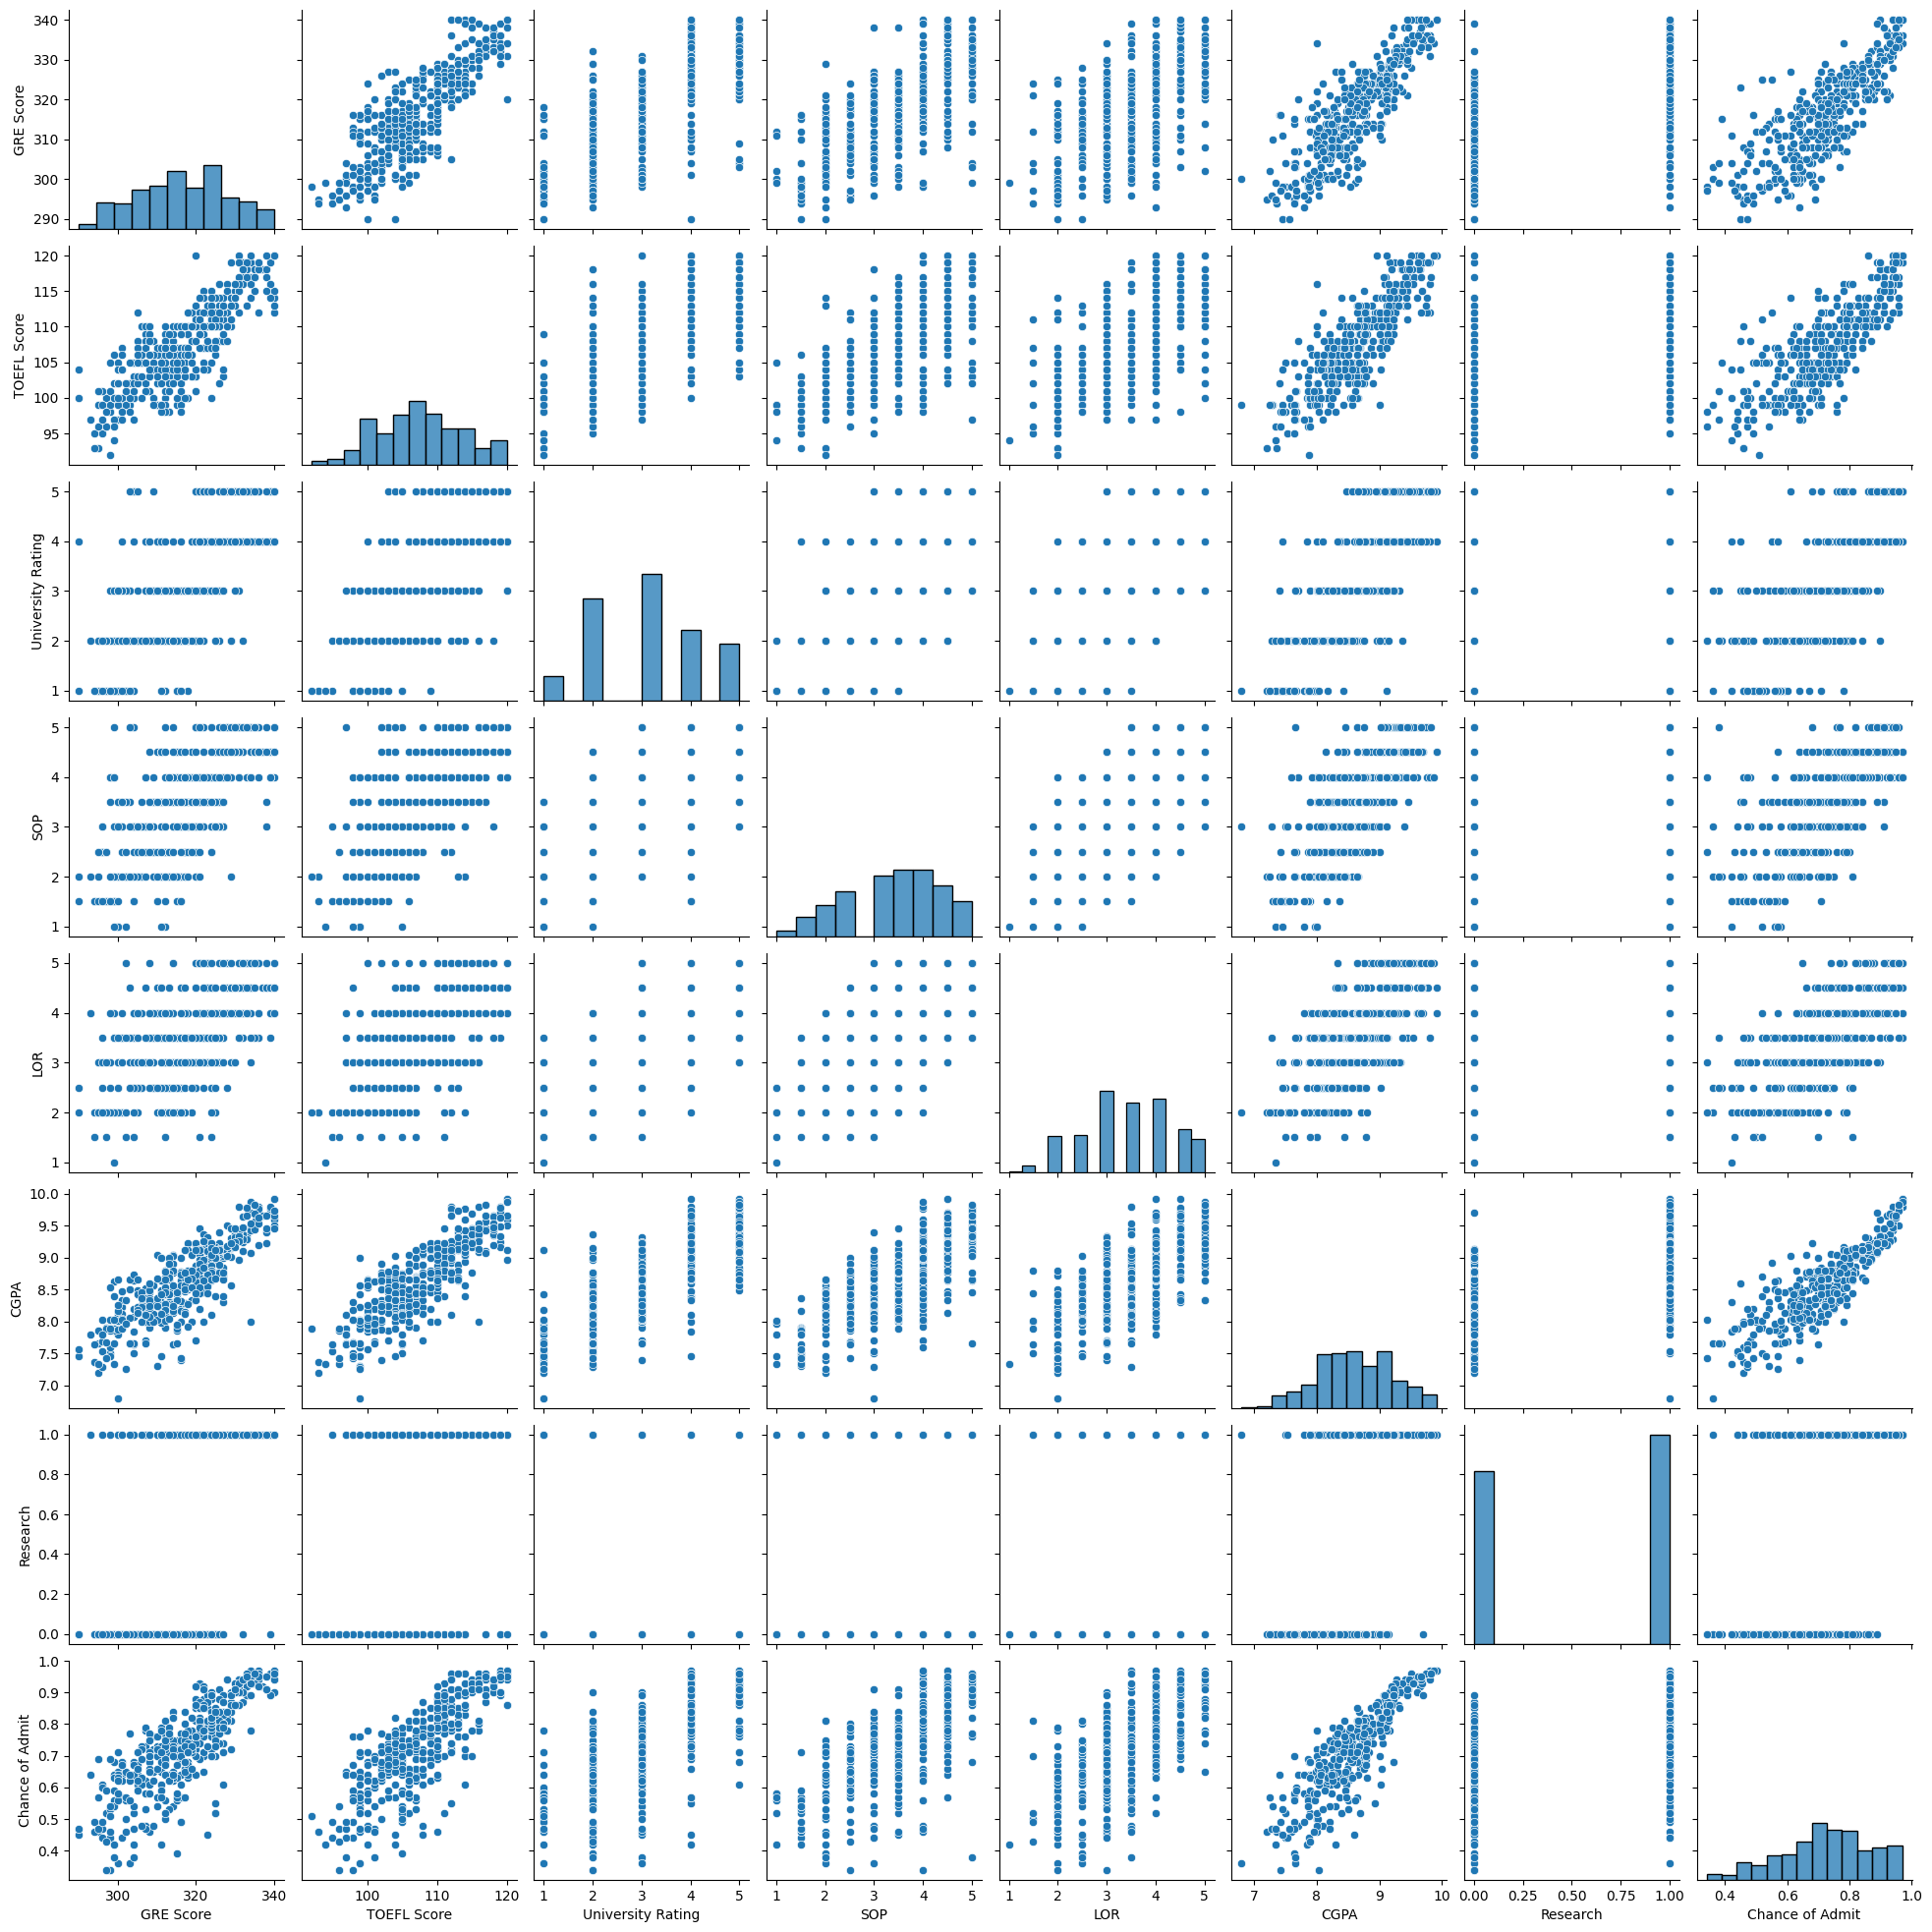

In [3]:
sns.pairplot(df)
plt.show()

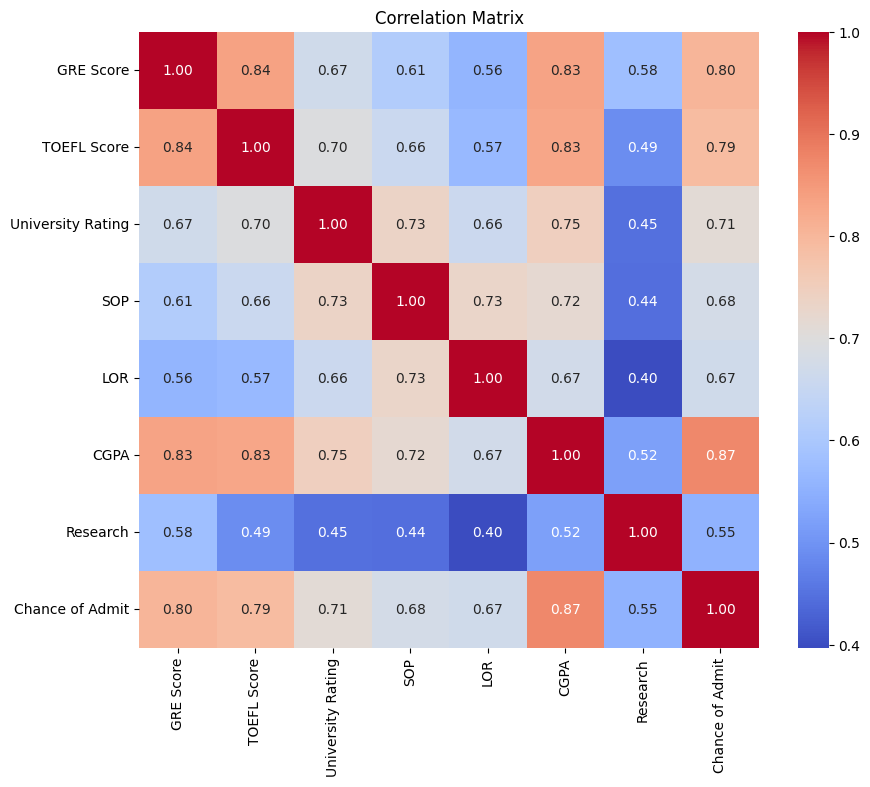

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Observation: CGPA and Chance of Admit (or GRE Score) generally show the highest correlation.

# 2. Linear Regression (Closed-Form Solution)
Here we set 'GRE Score' as the target variable and the remaining columns as features. We apply Standard Scaling to the features (an essential preprocessing step) and calculate the weights using the normal equation: $\theta = (X^T X)^{-1} X^T y$.

In [5]:
X_lin = df.drop('GRE Score', axis=1).values
y_lin = df['GRE Score'].values

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

scaler_lin = StandardScaler()
X_train_lin_s = scaler_lin.fit_transform(X_train_lin)
X_test_lin_s = scaler_lin.transform(X_test_lin)

X_train_lin_c = np.c_[np.ones(X_train_lin_s.shape[0]), X_train_lin_s]
X_test_lin_c = np.c_[np.ones(X_test_lin_s.shape[0]), X_test_lin_s]

theta_lin = np.linalg.inv(X_train_lin_c.T @ X_train_lin_c) @ X_train_lin_c.T @ y_train_lin

pred_train_lin = X_train_lin_c @ theta_lin
pred_test_lin = X_test_lin_c @ theta_lin

train_mse = mean_squared_error(y_train_lin, pred_train_lin)
test_mse = mean_squared_error(y_test_lin, pred_test_lin)

print(f"Linear Regression Train MSE: {train_mse:.4f}")
print(f"Linear Regression Test MSE: {test_mse:.4f}")

Linear Regression Train MSE: 26.9918
Linear Regression Test MSE: 31.9446


# 3. Closed-Form vs. Gradient Descent
**Advantages of Closed-Form:**
- Provides an exact analytical solution.
- No need to choose a learning rate (alpha) or iterate over epochs.

**Disadvantages & Why Gradient Descent is Preferred in Practice:**
- The closed-form solution requires computing the inverse of $X^T X$, which has a time complexity of $O(n^3)$.
- For datasets with a massive number of features (e.g., modern machine learning tasks), taking the inverse is computationally too slow.
- Gradient Descent scales beautifully to millions of features and rows. Additionally, Gradient Descent works even if $X^T X$ is not invertible (singular matrix issues).

# 4. Regularization: Lasso and Ridge Regression
We apply Lasso (L1) and Ridge (L2) regularizations to the same data to observe how different penalty functions affect the learned coefficients.

In [6]:
# Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_lin_s, y_train_lin)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_lin_s, y_train_lin)

feature_names_for_lin_reg = df.drop('GRE Score', axis=1).columns

# Create DataFrames for coefficients, explicitly naming the coefficient column
standard_coefficients_df = pd.DataFrame({'Feature': feature_names_for_lin_reg, 'Standard': theta_lin[1:]})
lasso_coefficients_df = pd.DataFrame({'Feature': feature_names_for_lin_reg, 'Lasso': lasso.coef_})
ridge_coefficients_df = pd.DataFrame({'Feature': feature_names_for_lin_reg, 'Ridge': ridge.coef_})

all_coefficients = standard_coefficients_df.merge(lasso_coefficients_df, on='Feature')
all_coefficients = all_coefficients.merge(ridge_coefficients_df, on='Feature')

display(all_coefficients)

,Feature,Standard,Lasso,Ridge
0,TOEFL Score,4.093146,3.733343,4.075694
1,University Rating,0.163120,0.000000,0.176385
2,SOP,-0.553352,0.000000,-0.538614
3,LOR,-0.355470,0.000000,-0.350855
4,CGPA,4.094036,3.479034,4.055533
5,Research,1.804908,1.183579,1.802599
6,Chance of Admit,1.785584,1.457506,1.805940


Observation: The results are exactly as expected. Lasso tends to perform feature selection by setting less important features to zero. Ridge shrinks all coefficients proportionally but rarely reduces them to exactly zero.

# 5. Logistic Regression with Newton-Raphson Optimization
We create a new binary target variable `Admitted` based on whether `Chance of Admit` is strictly greater than 0.5. After dropping the original probability column, we manually optimize the logistic regression weights using the Newton-Raphson method (with the Gradient and Hessian matrix).

Logistic Regression Train Accuracy: 95.00%
Logistic Regression Test Accuracy: 93.75%


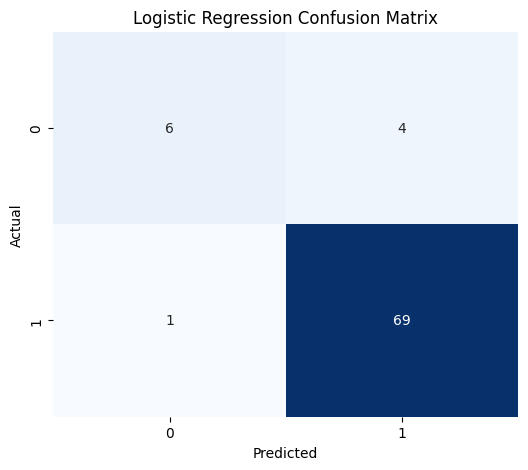

In [7]:
df['Admitted'] = (df['Chance of Admit'] > 0.5).astype(int)
df_log = df.drop('Chance of Admit', axis=1)

X_log = df_log.drop('Admitted', axis=1).values
y_log = df_log['Admitted'].values

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

scaler_log = StandardScaler()
X_train_log_s = scaler_log.fit_transform(X_train_log)
X_test_log_s = scaler_log.transform(X_test_log)

X_train_log_c = np.c_[np.ones(X_train_log_s.shape[0]), X_train_log_s]
X_test_log_c = np.c_[np.ones(X_test_log_s.shape[0]), X_test_log_s]

def sigmoid(z):
    z = np.clip(z, -250, 250) # Prevent overflow
    return 1 / (1 + np.exp(-z))

# Newton-Raphson Initialization
theta_log = np.zeros(X_train_log_c.shape[1])
epochs = 10

for i in range(epochs):
    h = sigmoid(X_train_log_c @ theta_log)
    gradient = X_train_log_c.T @ (h - y_train_log)

    # Weight matrix for Hessian
    W = np.diag(h * (1 - h))

    # Hessian Matrix with a small epsilon added to the diagonal to prevent singularity
    Hessian = X_train_log_c.T @ W @ X_train_log_c + np.eye(X_train_log_c.shape[1]) * 1e-5

    # Weight update
    theta_log = theta_log - np.linalg.inv(Hessian) @ gradient

# Predictions
pred_train_log = (sigmoid(X_train_log_c @ theta_log) >= 0.5).astype(int)
pred_test_log = (sigmoid(X_test_log_c @ theta_log) >= 0.5).astype(int)

accuracy_train = accuracy_score(y_train_log, pred_train_log)
accuracy_test = accuracy_score(y_test_log, pred_test_log)

print(f"Logistic Regression Train Accuracy: {accuracy_train*100:.2f}%")
print(f"Logistic Regression Test Accuracy: {accuracy_test*100:.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_log, pred_test_log), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Feature Importance Analysis
By mapping the calculated logistic regression coefficients back to the feature names, we can determine the importance of each feature.

In [8]:
feature_names = df_log.drop('Admitted', axis=1).columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': theta_log[1:]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
display(coef_df)

,Feature,Coefficient
5,CGPA,1.975011
1,TOEFL Score,1.208795
4,LOR,0.920018
0,GRE Score,0.482154
6,Research,-0.257574
3,SOP,-0.444549
2,University Rating,-0.906316


Observation: CGPA has the highest positive coefficient, making it the most critical factor for predicting university admission. This perfectly matches the early findings derived from our exploratory pairplot and correlation heatmap.